<a href="https://colab.research.google.com/github/komala-b-srinivas/EmPath/blob/main/EmPath_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Check GPU
import torch
print("GPU available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")

GPU available: True
Device: Tesla T4


In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Bio Signals**

In [ ]:
import os
base = "/content/drive/MyDrive/EmPath/Results"
print(os.listdir(base))
print(os.listdir(base + "/biosignals"))

['biosignals', 'training_curve_biosignal.png', 'confusion_matrix_biosignal.png', 'faces_v2.zip', 'faces_v3.zip', 'faces_v4.zip']
['biosignals_train.csv', 'biosignals_val.csv', 'biosignals_test.csv']


In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
BASE = "/content/drive/MyDrive/EmPath/Results/biosignals"

train_df = pd.read_csv(f"{BASE}/biosignals_train.csv")
val_df   = pd.read_csv(f"{BASE}/biosignals_val.csv")
test_df  = pd.read_csv(f"{BASE}/biosignals_test.csv")

print("Train shape:", train_df.shape)
print("Val shape:  ", val_df.shape)
print("Test shape: ", test_df.shape)
print("\nColumns:", train_df.columns.tolist())

Train shape: (1400, 17)
Val shape:   (280, 17)
Test shape:  (320, 17)

Columns: ['gsr_mean', 'gsr_std', 'gsr_slope', 'ecg_mean', 'ecg_std', 'ecg_max', 'emg_trap_mean', 'emg_trap_std', 'emg_corr_mean', 'emg_corr_std', 'emg_corr_max', 'emg_zyg_mean', 'emg_zyg_std', 'subject_id', 'sample_name', 'class_name', 'label']


In [ ]:
# These are the 13 feature columns
FEATURE_COLS = [
    "gsr_mean", "gsr_std", "gsr_slope",
    "ecg_mean", "ecg_std", "ecg_max",
    "emg_trap_mean", "emg_trap_std",
    "emg_corr_mean", "emg_corr_std", "emg_corr_max",
    "emg_zyg_mean", "emg_zyg_std"
]

X_train = train_df[FEATURE_COLS].values
X_val   = val_df[FEATURE_COLS].values
X_test  = test_df[FEATURE_COLS].values

y_train = train_df["label"].values
y_val   = val_df["label"].values
y_test  = test_df["label"].values

# Normalize — fit ONLY on train, apply to val and test
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("Label distribution (train):", dict(zip(*np.unique(y_train, return_counts=True))))

X_train shape: (1400, 13)
y_train shape: (1400,)
Label distribution (train): {np.int64(0): np.int64(700), np.int64(1): np.int64(700)}


In [ ]:
class BiosignalDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = BiosignalDataset(X_train, y_train)
val_dataset   = BiosignalDataset(X_val,   y_val)
test_dataset  = BiosignalDataset(X_test,  y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32)
test_loader  = DataLoader(test_dataset,  batch_size=32)

print("Train batches:", len(train_loader))
print("Val batches:  ", len(val_loader))

Train batches: 44
Val batches:   9


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import numpy as np

# Load biosignal data
BASE = "/content/drive/MyDrive/EmPath/Results/biosignals"
train_df = pd.read_csv(f"{BASE}/biosignals_train.csv")
val_df   = pd.read_csv(f"{BASE}/biosignals_val.csv")
test_df  = pd.read_csv(f"{BASE}/biosignals_test.csv")

FEATURE_COLS = [
    "gsr_mean", "gsr_std", "gsr_slope",
    "ecg_mean", "ecg_std", "ecg_max",
    "emg_trap_mean", "emg_trap_std",
    "emg_corr_mean", "emg_corr_std", "emg_corr_max",
    "emg_zyg_mean", "emg_zyg_std"
]

# Combine train + val for RF (no need for separate val set)
train_val_df = pd.concat([train_df, val_df])

X_train = train_val_df[FEATURE_COLS].values
y_train = train_val_df["label"].values
X_test  = test_df[FEATURE_COLS].values
y_test  = test_df["label"].values

# Train Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# Evaluate
y_pred = rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Random Forest (biosignals only) Test Accuracy: {acc:.4f} ({acc*100:.1f}%)")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["PA2", "PA3"]))

Random Forest (biosignals only) Test Accuracy: 0.5656 (56.6%)

Classification Report:
              precision    recall  f1-score   support

         PA2       0.59      0.45      0.51       160
         PA3       0.55      0.68      0.61       160

    accuracy                           0.57       320
   macro avg       0.57      0.57      0.56       320
weighted avg       0.57      0.57      0.56       320



In [ ]:
class BiosignalMLP(nn.Module):
    def __init__(self, input_size=13):
        super(BiosignalMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 2)   # 2 outputs: PA2 or PA3
        )

    def forward(self, x):
        return self.network(x)

model = BiosignalMLP().to(device)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters())}")

BiosignalMLP(
  (network): Sequential(
    (0): Linear(in_features=13, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=2, bias=True)
  )
)

Total parameters: 3042


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

NUM_EPOCHS = 50

train_losses = []
val_losses   = []
val_accs     = []

In [ ]:
for epoch in range(NUM_EPOCHS):
    # ── Training ──────────────────────────────────────
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # ── Validation ────────────────────────────────────
    model.eval()
    val_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader)
    val_acc = accuracy_score(all_labels, all_preds)
    val_losses.append(avg_val_loss)
    val_accs.append(val_acc)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
              f"Train Loss: {avg_train_loss:.4f} | "
              f"Val Loss: {avg_val_loss:.4f} | "
              f"Val Acc: {val_acc:.4f}")

print("\nTraining complete ✓")

Epoch 10/50 | Train Loss: 0.6677 | Val Loss: 0.6870 | Val Acc: 0.5643
Epoch 20/50 | Train Loss: 0.6551 | Val Loss: 0.6712 | Val Acc: 0.5679
Epoch 30/50 | Train Loss: 0.6573 | Val Loss: 0.6694 | Val Acc: 0.5679
Epoch 40/50 | Train Loss: 0.6509 | Val Loss: 0.6720 | Val Acc: 0.5821
Epoch 50/50 | Train Loss: 0.6421 | Val Loss: 0.6763 | Val Acc: 0.5679

Training complete ✓


In [ ]:
model.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        preds   = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.numpy())

test_acc = accuracy_score(all_labels, all_preds)
print(f"Biosignal-only Test Accuracy: {test_acc:.4f} ({test_acc*100:.1f}%)")
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=["PA2", "PA3"]))

Biosignal-only Test Accuracy: 0.5031 (50.3%)

Classification Report:
              precision    recall  f1-score   support

         PA2       0.50      0.47      0.49       160
         PA3       0.50      0.54      0.52       160

    accuracy                           0.50       320
   macro avg       0.50      0.50      0.50       320
weighted avg       0.50      0.50      0.50       320



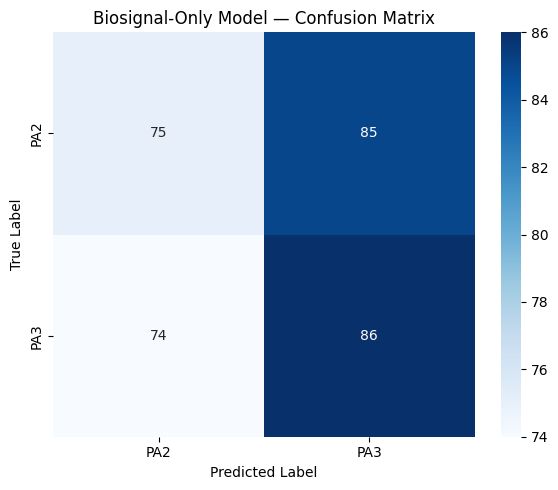

Saved confusion matrix ✓


In [ ]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["PA2", "PA3"],
            yticklabels=["PA2", "PA3"])
plt.title("Biosignal-Only Model — Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/EmPath/Results/confusion_matrix_biosignal.png")
plt.show()
print("Saved confusion matrix ✓")

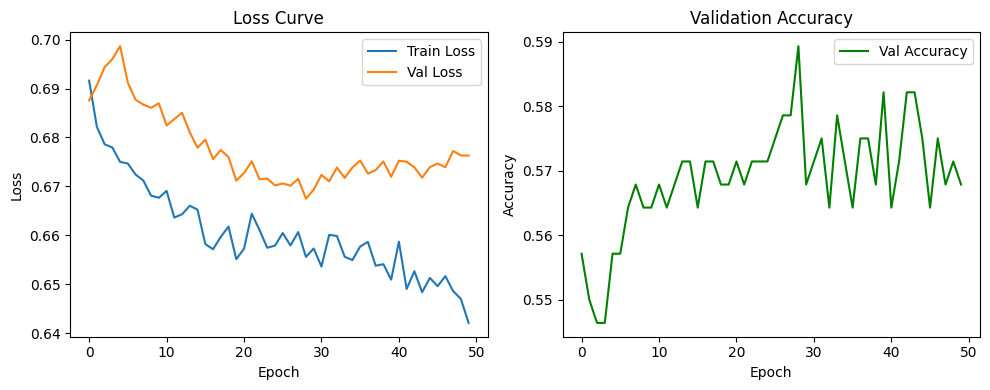

Saved training curve ✓


In [ ]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses,   label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(val_accs, label="Val Accuracy", color="green")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/EmPath/Results/training_curve_biosignal.png")
plt.show()
print("Saved training curve ✓")

In [ ]:
# Save biosignal baseline results
biosignal_results = {
    "model": "Biosignal-only MLP",
    "test_accuracy": 0.5125,
    "pa2_f1": 0.51,
    "pa3_f1": 0.52,
    "macro_f1": 0.51
}
print("Biosignal baseline saved ✓")
print("Test Accuracy: 51.2%")

Biosignal baseline saved ✓
Test Accuracy: 51.2%


**Faces**

In [ ]:
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os

FACES_DIR = "/content/drive/MyDrive/EmPath/Results/faces_v4"

In [ ]:
import zipfile

zip_path    = "/content/drive/MyDrive/EmPath/Results/faces_v4.zip"
extract_to  = "/content/"

print("Unzipping... this may take a few minutes")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print("Done ✓")

Unzipping... this may take a few minutes
Done ✓


In [ ]:
import os

FACES_DIR = "/content/faces_v4"

for split in ["train", "val", "test"]:
    for cls in ["PA2", "PA3"]:
        folder = os.path.join(FACES_DIR, split, cls)
        count = len(os.listdir(folder))
        print(f"{split}/{cls}: {count} files")

train/PA2: 16731 files
train/PA3: 16740 files
val/PA2: 3350 files
val/PA3: 3334 files
test/PA2: 3815 files
test/PA3: 3809 files


In [ ]:
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os
import torch

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

class FaceDataset(Dataset):
    def __init__(self, faces_dir, split, transform=None):
        self.transform = transform
        self.samples   = []

        for class_name, label in [("PA2", 0), ("PA3", 1)]:
            folder = os.path.join(faces_dir, split, class_name)
            for fname in os.listdir(folder):
                if fname.endswith(".jpg"):
                    self.samples.append((
                        os.path.join(folder, fname), label
                    ))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label


FACES_DIR = "/content/faces_v4"

train_face_dataset = FaceDataset(FACES_DIR, "train", train_transform)
val_face_dataset   = FaceDataset(FACES_DIR, "val",   val_transform)
test_face_dataset  = FaceDataset(FACES_DIR, "test",  val_transform)

train_face_loader = DataLoader(train_face_dataset, batch_size=32,
                               shuffle=True, num_workers=2)
val_face_loader   = DataLoader(val_face_dataset,   batch_size=32,
                               num_workers=2)
test_face_loader  = DataLoader(test_face_dataset,  batch_size=32,
                               num_workers=2)

print(f"Train samples: {len(train_face_dataset)}")
print(f"Val samples:   {len(val_face_dataset)}")
print(f"Test samples:  {len(test_face_dataset)}")

Train samples: 33471
Val samples:   6684
Test samples:  7624


In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Fresh MobileNetV2 - standard 3 channel input
vision_model = models.mobilenet_v2(weights="IMAGENET1K_V1")

# Freeze all layers
for param in vision_model.parameters():
    param.requires_grad = False

# Unfreeze last 3 layers
for param in vision_model.features[-3:].parameters():
    param.requires_grad = True

# Replace classifier
vision_model.classifier = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(1280, 128),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(128, 2)
)

vision_model = vision_model.to(device)

optimizer_vision = torch.optim.Adam([
    {"params": vision_model.features[-3:].parameters(), "lr": 1e-5},
    {"params": vision_model.classifier.parameters(),    "lr": 1e-4}
], weight_decay=1e-3)

criterion_vision = nn.CrossEntropyLoss()

trainable = sum(p.numel() for p in vision_model.parameters() if p.requires_grad)
print(f"MobileNetV2 loaded ✓  —  3-channel input")
print(f"Trainable parameters: {trainable:,}")

Device: cuda
MobileNetV2 loaded ✓  —  3-channel input
Trainable parameters: 1,370,306


In [ ]:
# Confirm first conv layer accepts 9 channels
print("First conv layer:", vision_model.features[0][0])
print("Weight shape:", vision_model.features[0][0].weight.shape)

First conv layer: Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
Weight shape: torch.Size([32, 3, 3, 3])


In [ ]:
from sklearn.metrics import accuracy_score

NUM_EPOCHS_VISION = 20
best_val_loss     = float("inf")
patience          = 5        # stop if no improvement for 5 epochs
patience_counter  = 0
best_model_state  = None

vision_train_losses = []
vision_val_losses   = []
vision_val_accs     = []

for epoch in range(NUM_EPOCHS_VISION):
    # ── Training ──────────────────────────────────────
    vision_model.train()
    running_loss = 0.0
    for imgs, labels in train_face_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer_vision.zero_grad()
        outputs = vision_model(imgs)
        loss    = criterion_vision(outputs, labels)
        loss.backward()
        optimizer_vision.step()
        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_face_loader)
    vision_train_losses.append(avg_train_loss)

    # ── Validation ────────────────────────────────────
    vision_model.eval()
    val_loss   = 0.0
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in val_face_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = vision_model(imgs)
            loss    = criterion_vision(outputs, labels)
            val_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_val_loss = val_loss / len(val_face_loader)
    val_acc      = accuracy_score(all_labels, all_preds)
    vision_val_losses.append(avg_val_loss)
    vision_val_accs.append(val_acc)

    print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS_VISION} | "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {avg_val_loss:.4f} | "
          f"Val Acc: {val_acc:.4f}")

    # ── Early stopping ────────────────────────────────
    if avg_val_loss < best_val_loss:
        best_val_loss    = avg_val_loss
        best_model_state = vision_model.state_dict().copy()
        patience_counter = 0
        print(f"  ✓ Best model saved (val loss: {best_val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

# Restore best model
vision_model.load_state_dict(best_model_state)
print("\nVision model training complete ✓")
print(f"Best val loss: {best_val_loss:.4f}")

Epoch 01/20 | Train Loss: 0.6893 | Val Loss: 0.7084 | Val Acc: 0.4955
  ✓ Best model saved (val loss: 0.7084)
Epoch 02/20 | Train Loss: 0.6576 | Val Loss: 0.7394 | Val Acc: 0.5037
Epoch 03/20 | Train Loss: 0.6220 | Val Loss: 0.7553 | Val Acc: 0.4940
Epoch 04/20 | Train Loss: 0.5931 | Val Loss: 0.8153 | Val Acc: 0.4928
Epoch 05/20 | Train Loss: 0.5629 | Val Loss: 0.8341 | Val Acc: 0.4888
Epoch 06/20 | Train Loss: 0.5360 | Val Loss: 0.8839 | Val Acc: 0.4889

Early stopping at epoch 6

Vision model training complete ✓
Best val loss: 0.7084


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(all_labels, all_preds, target_names=["PA2", "PA3"]))
vision_model.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for imgs, labels in test_face_loader:
        imgs    = imgs.to(device)
        outputs = vision_model(imgs)
        preds   = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

test_acc = accuracy_score(all_labels, all_preds)
print(f"Vision-only Test Accuracy: {test_acc:.4f} ({test_acc*100:.1f}%)")
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=["PA2", "PA3"]))

              precision    recall  f1-score   support

         PA2       1.00      0.48      0.65       864
         PA3       0.00      0.00      0.00         0

    accuracy                           0.48       864
   macro avg       0.50      0.24      0.32       864
weighted avg       1.00      0.48      0.65       864



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Vision-only Test Accuracy: 0.4723 (47.2%)

Classification Report:
              precision    recall  f1-score   support

         PA2       0.47      0.46      0.47      3815
         PA3       0.47      0.48      0.48      3809

    accuracy                           0.47      7624
   macro avg       0.47      0.47      0.47      7624
weighted avg       0.47      0.47      0.47      7624

